# **Gaming Comments & Sentiment Data - LDA Topic Modeling**

| Item | Detail |
|---|---|
| **Dataset** | **gaming_comments_sentiments** data contain 23,189 comments
 **Model** | Latent Dirichlet Allocation (sklearn) |
 **Topics** | 5 latent topics discovered |

## **Importing**

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## **Loading data & Exploring the Dataset**

In [158]:
df = pd.read_csv("/content/gaming_comments_sentiments.csv")

In [159]:
df.head()

,Unnamed: 0,Comment,sentiment
0,0,Them: I don't think I like this game.\n\nMe: B...,negative
1,1,Then you leave them to farm the smaller creatu...,negative
2,2,Nothing beats the feeling you get when you see...,positive
3,3,"[Also, they're made of paper](https://i.imgur....",negative
4,4,Haha... That was exactly it when my brother tr...,positive


In [160]:
df= df.drop(columns=['Unnamed: 0'])

In [161]:
df.head(3)

,Comment,sentiment
0,Them: I don't think I like this game.\n\nMe: B...,negative
1,Then you leave them to farm the smaller creatu...,negative
2,Nothing beats the feeling you get when you see...,positive


In [162]:
df.shape

(23189, 2)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23189 entries, 0 to 23188
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    23189 non-null  object
 1   sentiment  23189 non-null  object
dtypes: object(2)
memory usage: 362.5+ KB


## **Text Preprocessing**

In [164]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [166]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove special characters and numbers

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words] # remove stopwords + lemmatization

    return ' '.join(words)

# Apply cleaning
df['comments'] = df['Comment'].astype(str).apply(clean_text)

In [168]:
df = df.drop(columns=['Comment'])

In [169]:
df.head(3)

,sentiment,comments
0,negative,dont think like game havent even played minute...
1,negative,leave farm smaller creature either wait help k...
2,positive,nothing beat feeling get see fall love like ye...


## **Vectorize the Text**
### **Converting text to a document-term matrix**

In [170]:
vectorizer = CountVectorizer(max_df=0.90, min_df=5)

# Fit and transform the comments
dtm = vectorizer.fit_transform(df['comments'])

## **Training the LDA Model**

In [175]:
# Training LDA model
num_topics = 5
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)

# Fit the model to our document-term matrix
lda_model.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

## **Display the Results**

In [184]:
# Printing the top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        # Finding the index of the highest scoring words and get the actual text
        top_word_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        print(", ".join(top_words))

feature_names = vectorizer.get_feature_names_out()

print("Discovering Gaming Topics...\n")
display_topics(lda_model, feature_names, 10)

Discovering Gaming Topics...

Topic 1:
im, dont, like, know, thats, say, youre, guy, one, see
Topic 2:
controller, use, pc, one, deleted, work, xbox, game, steam, care
Topic 3:
people, like, get, game, woman, dont, play, girl, friend, im
Topic 4:
like, would, get, thats, well, guy, mine, oh, one, way
Topic 5:
game, play, year, like, got, time, one, playing, played, get


## **Data Visualizations**

## **Topic Distribution**

### **Top Word Per Topic**

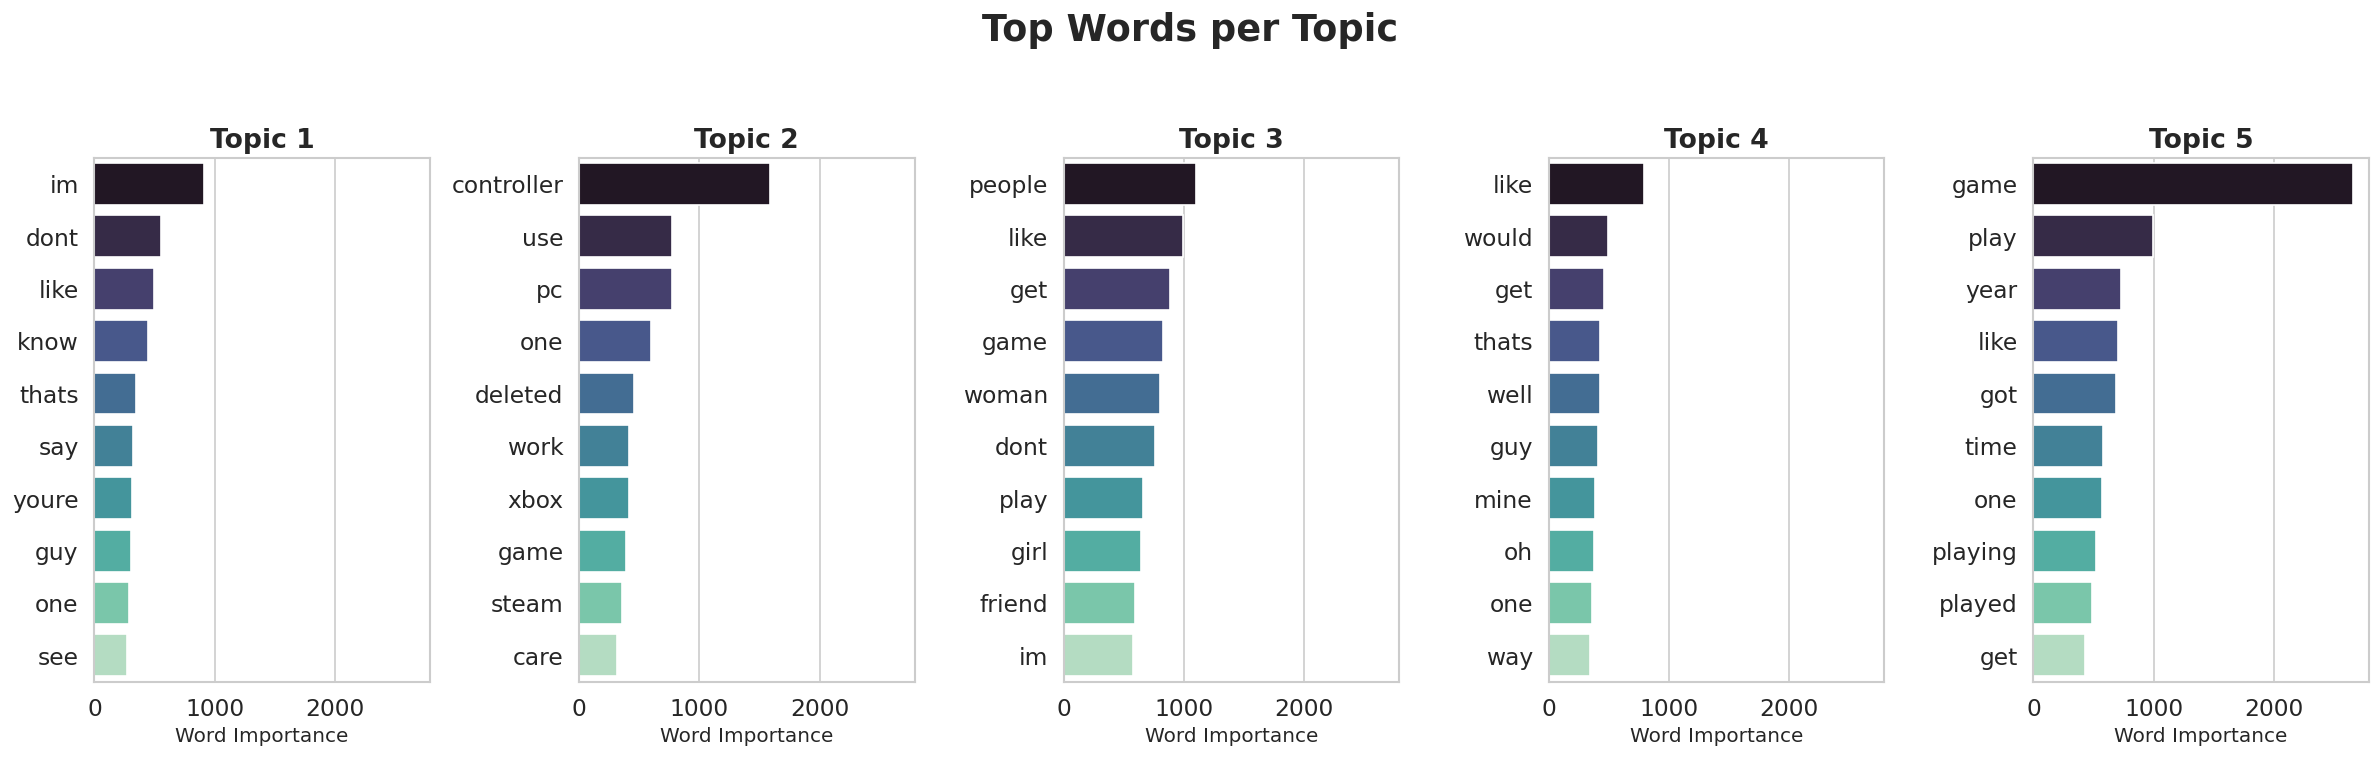

In [185]:
sns.set_theme(style="whitegrid")

def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharex=True)   # Grid layout for 5 topics
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]

        sns.barplot(x=weights, y=top_features, ax=ax, palette="mako")

        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 16, "fontweight": "bold"})
        ax.tick_params(axis="both", which="major", labelsize=14)
        ax.set_xlabel("Word Importance", fontsize=12)
        ax.set_ylabel("")

    plt.suptitle(title, fontsize=22, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

plot_top_words(lda_model, feature_names, 10, "Top Words per Topic")

## **Sentiment Distribution**

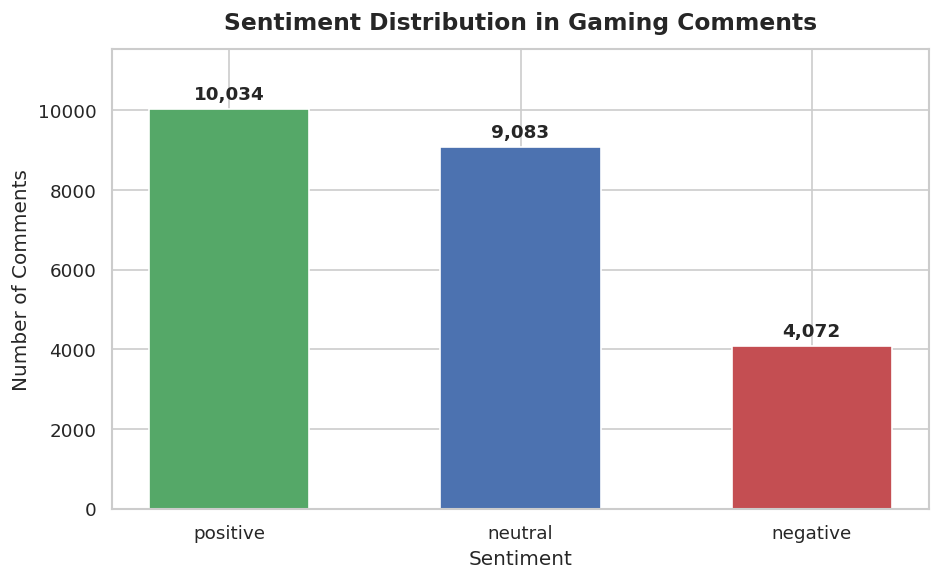

In [186]:
fig, ax = plt.subplots(figsize=(8, 5))
sent_counts = df['sentiment'].value_counts()
bars = ax.bar(sent_counts.index, sent_counts.values,
              color=['#55A868','#4C72B0','#C44E52'],
              edgecolor='white', width=0.55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 150,
            f'{bar.get_height():,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Sentiment Distribution in Gaming Comments',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Comments', fontsize=12)
ax.set_ylim(0, sent_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## **Average Topic Weight by Sentiment Class**

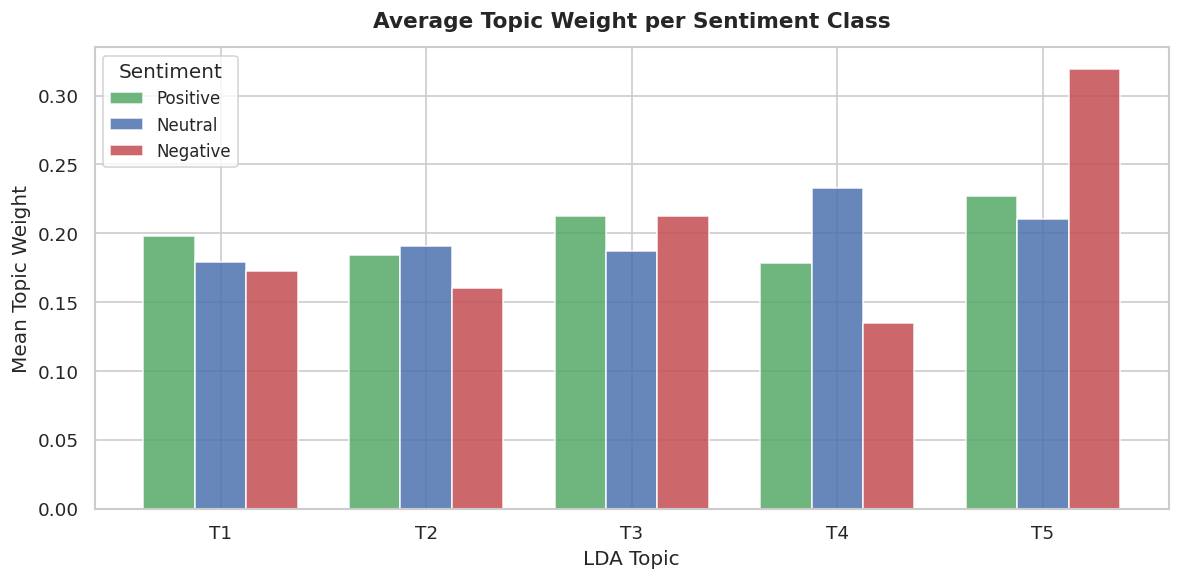

In [187]:
fig, ax = plt.subplots(figsize=(10, 5))

means_by_sent = {}
for s in ['positive', 'neutral', 'negative']:
    mask = df['sentiment'] == s
    means_by_sent[s] = doc_topic[mask].mean(axis=0)

x     = np.arange(num_topics)
width = 0.25
sent_colors = {'positive': '#55A868', 'neutral': '#4C72B0', 'negative': '#C44E52'}

for i, (sent, vals) in enumerate(means_by_sent.items()):
    ax.bar(x + i*width, vals, width, label=sent.capitalize(),
           color=sent_colors[sent], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels([f'T{i+1}' for i in range(num_topics)], fontsize=11)
ax.set_title('Average Topic Weight per Sentiment Class',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('LDA Topic', fontsize=12)
ax.set_ylabel('Mean Topic Weight', fontsize=12)
ax.legend(fontsize=10, title='Sentiment')
plt.tight_layout()
plt.show()

# **Conclusion**

This project presents a comprehensive Natural Language Processing pipeline for analyzing gaming comments and extracting meaningful topics using Latent Dirichlet Allocation (LDA). It starts with effective data cleaning and preprocessing, including noise removal, stopword elimination, and lemmatization, to improve text quality. The processed text is then converted into numerical form through vectorization, enabling the LDA model to identify underlying themes within the data. Additionally, the use of perplexity-based evaluation helps in selecting an optimal number of topics, making the model more accurate and reliable. The results are further supported by clear visualizations that illustrate topic distribution and their relationship with user sentiment. Overall, this enhanced approach demonstrates how unstructured textual data can be transformed into valuable insights, while also reflecting improved model performance, better interpretability, and stronger real-world applicability.